# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb", "huggingface_hub"], check=True)
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
else:
    hf_token = os.environ.get("HF_TOKEN")

import duckdb, pandas as pd, numpy as np, json
con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql(f"CREATE OR REPLACE SECRET hf_token (TYPE HUGGINGFACE, TOKEN '{hf_token}');")

MONTH = "2026-03"
BASE = "hf://datasets/FlyRank/internship-warehouse"
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

raw = con.sql(f"""
    SELECT
        f.content_hash_id, f.client_hash_id, f.report_date,
        f.gsc_clicks, f.gsc_impressions, f.gsc_avg_position,
        c.content_type, c.word_count, c.content_created_date, c.is_deleted, c.is_published
    FROM read_parquet('{BASE}/fact_content_daily_performance/month={MONTH}/*.parquet') f
    JOIN read_parquet('{BASE}/dim_content.parquet') c ON f.content_hash_id = c.content_hash_id
    WHERE c.is_deleted = FALSE AND c.is_published = TRUE
""").df()

agg = raw.groupby("content_hash_id").agg(
    client_hash_id=("client_hash_id", "first"),
    gsc_clicks=("gsc_clicks", "sum"),
    gsc_impressions=("gsc_impressions", "sum"),
    gsc_avg_position=("gsc_avg_position", "mean"),
    content_type=("content_type", "first"),
    word_count=("word_count", "first"),
    content_created_date=("content_created_date", "first"),
).reset_index()
agg["ctr"] = (agg["gsc_clicks"] / agg["gsc_impressions"].replace(0, np.nan)).fillna(0).round(4)
agg["content_age_days"] = (pd.Timestamp(f"{MONTH}-01") - pd.to_datetime(agg["content_created_date"])).dt.days

agg_filtered = agg[agg["gsc_impressions"] >= 20].copy()
agg_filtered["position_tier"] = pd.cut(agg_filtered["gsc_avg_position"],
                                         bins=[0, 3, 10, 20, 1000],
                                         labels=["top_3", "page_1", "page_2_3", "deep"])
agg_filtered["tier_avg_ctr"] = agg_filtered.groupby("position_tier", observed=True)["ctr"].transform("mean")
agg_filtered["ctr_gap"] = agg_filtered["tier_avg_ctr"] - agg_filtered["ctr"]

print(f"{len(agg_filtered):,} pages in working set")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

132,471 pages in working set


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*



The playbook is built on the **baseline rule** (`ctr_underperformer_for_tier`), not the trained
models — per the honest comparison in ML-08/ML-09, the baseline performed at least as well as,
and slightly better than, both trained models at larger K. Using the simpler, fully transparent
rule as the actual recommendation mechanism is the honest choice here, matching the
`training-honest-models` principle that complexity should only be rewarded when it earns its
place.

In [2]:
scored = agg_filtered[
    (agg_filtered["gsc_impressions"] >= 500) &
    (agg_filtered["gsc_avg_position"] > 0) & (agg_filtered["gsc_avg_position"] <= 20)
].copy()

scored["score"] = scored["ctr_gap"].clip(lower=0)
scored["reason_code"] = "ctr_underperformer_for_tier"

# Split into two actions based on the measurement-anomaly finding from ML-07's top-20 review
scored["action"] = np.where(
    scored["ctr"] == 0,
    "check_tracking_then_review_title_meta",
    "review_title_meta"
)

queue = scored.sort_values(["score", "gsc_impressions"], ascending=[False, False])[
    ["content_hash_id", "client_hash_id", "gsc_impressions", "gsc_avg_position",
     "position_tier", "ctr", "tier_avg_ctr", "ctr_gap", "score", "reason_code", "action"]
].reset_index(drop=True)

print(f"{len(queue):,} pages in the ranked action queue")
print(f"Action breakdown:\n{queue['action'].value_counts()}")
queue.head(10)

50,752 pages in the ranked action queue
Action breakdown:
action
review_title_meta                        43449
check_tracking_then_review_title_meta     7303
Name: count, dtype: int64


,content_hash_id,client_hash_id,gsc_impressions,gsc_avg_position,position_tier,ctr,tier_avg_ctr,ctr_gap,score,reason_code,action
0,content_d61fc394d10cba41,client_1a730cb2640a1abf,38000,2.740744,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
1,content_66bf45eb0c5bb550,client_fef1a8f436438636,24259,2.784944,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
2,content_fa17add7836d36c3,client_a80fca3f171ed1de,12588,1.902457,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
3,content_d397987113cb84a0,client_73cda7b4e4f265ea,9887,1.953104,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
4,content_a27b382f00aa75c6,client_23a62021009f63c4,7736,2.259812,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
5,content_83167156f76e33e5,client_e547b89c05043229,6827,1.136714,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
6,content_1bc8782404e3b132,client_fef1a8f436438636,5792,2.264276,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
7,content_76a6fa55e21323b3,client_0fa64a184f18a4a0,5041,2.855291,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
8,content_9cec93fc44a7ab41,client_20259bd6705d81d4,4742,1.852298,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
9,content_fd1d19e381fc653e,client_73cda7b4e4f265ea,4319,2.789944,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta


**What this queue tells a reviewer:** each row is a page that is visible (500+ impressions),
well-positioned (position 1-20), and underperforming its own position tier's typical CTR — this
is *observed*, on this March 2026 slice, and *directional*, not a guarantee. The score ranks
by size of the gap, tie-broken by impression volume so the highest-stakes opportunities surface
first.

**Two reason-linked actions, not one:** per the finding in ML-07's top-20 review, pages with
exactly 0% CTR despite strong position and real traffic are unusual enough to warrant a
tracking/measurement check *before* assuming the content itself is the problem — so those rows
get `check_tracking_then_review_title_meta` instead of a blind content-fix instruction.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*



**Who uses this:** a content or SEO reviewer with limited weekly review capacity, using the
ranked queue to decide which pages to open first — not an automated pipeline that edits pages
on its own.

**What it's for:** prioritizing manual review among many candidate pages — *decision-support*,
per the claim ladder, not a promise that any specific page will improve if edited.

**Where it stops being valid:**
- **Time window:** built on March 2026 data only. A different month could shift which pages
  qualify, since traffic and rankings move.
- **Cross-sectional, not causal:** this is a single snapshot, not an experiment. It cannot say
  "editing this page will increase its CTR" — only that the page currently looks worth
  reviewing, per the claim ladder's explicit rule that cross-sectional data never supports
  "doing X will produce Y."
- **Selection bias risk:** if reviewers only ever act on the top of this queue, any future
  comparison of "reviewed vs. unreviewed" pages would be biased by that choice itself, not a
  clean measure of the fix's effect — worth naming now, before anyone runs that comparison.
- **Single-client generalization is unverified:** ML-09 found the honest grouped-split accuracy
  gap wasn't fully stable across a single fold — this queue should not be assumed equally
  reliable across every one of the 70 clients in the warehouse without further per-client
  checking.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*



**What a person must check before acting on any row:**
- Confirm the page is still live and not already mid-edit or mid-migration
- For `check_tracking_then_review_title_meta` rows specifically: verify tracking/redirect setup
  before touching content, since a real measurement gap (not a content gap) would make a
  content edit pointless
- Sanity-check that the page's current content genuinely matches its ranking query's intent —
  this queue cannot detect a content-type/intent mismatch (per the MIXED verdict on
  `content_type` in ML-06), only a CTR gap

**What should NOT be automated:**
- **Never auto-publish content or title/meta changes** from this queue — every row needs a human
  editor's judgment; this is a prioritization tool, not a content-generation or auto-fix tool.
- **Never treat the score as a guarantee of impact** — per the claim ladder, this is
  decision-support language only ("worth reviewing"), never "will improve."
- **Never remove or de-index a page based on this queue alone** — a low score or exclusion from
  the queue does not mean a page is worthless; it may simply fall below the visibility/position
  filters used to build this specific queue.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*



**Signals that this playbook has gone stale and needs a refresh:**
- **Monthly re-run:** since this is built on a single month's snapshot, the queue should be
  regenerated each month rather than reused indefinitely — position and CTR shift over time.
- **Base rate drift:** if the label's base rate (currently ~0.50 in ML-08/09) shifts
  substantially in a new month, the CTR-median threshold itself may need re-examining, since a
  skewed base rate changes what "underperforming" means.
- **Tier-spread collapse:** if the CTR spread across position tiers (currently ~0.0025 per
  ML-06/07) shrinks significantly in future data, the core assumption behind this rule — that
  CTR meaningfully depends on position tier — would need re-verifying before trusting the queue.
- **Reviewed-page outcome tracking:** once reviewers act on rows from this queue, tracking
  before/after CTR on those specific pages (with the selection-bias caveat from Section 2 kept
  in mind) would be the strongest available signal for whether the rule is still working.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [3]:
queue.to_csv("work/outputs/baseline_action_score.csv", index=False)

metrics = {
    "month": MONTH,
    "n_pages_working_set": int(len(agg_filtered)),
    "n_pages_in_queue": int(len(queue)),
    "action_breakdown": queue["action"].value_counts().to_dict(),
    "reason_codes": queue["reason_code"].unique().tolist(),
    "ctr_tier_spread": round(float(agg_filtered.groupby("position_tier", observed=True)["ctr"].mean().max()
                              - agg_filtered.groupby("position_tier", observed=True)["ctr"].mean().min()), 4),
    "baseline_vs_model_note": "baseline (ctr_gap rule) performed at least as well as trained "
                               "models at precision@200/500 per ML-08/ML-09 (see those notebooks "
                               "for full comparison table).",
}

with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Exported: work/outputs/baseline_action_score.csv")
print("Exported: work/outputs/playbook_metrics.json")
print(json.dumps(metrics, indent=2))

Exported: work/outputs/baseline_action_score.csv
Exported: work/outputs/playbook_metrics.json
{
  "month": "2026-03",
  "n_pages_working_set": 132471,
  "n_pages_in_queue": 50752,
  "action_breakdown": {
    "review_title_meta": 43449,
    "check_tracking_then_review_title_meta": 7303
  },
  "reason_codes": [
    "ctr_underperformer_for_tier"
  ],
  "ctr_tier_spread": 0.0025,
  "baseline_vs_model_note": "baseline (ctr_gap rule) performed at least as well as trained models at precision@200/500 per ML-08/ML-09 (see those notebooks for full comparison table)."
}


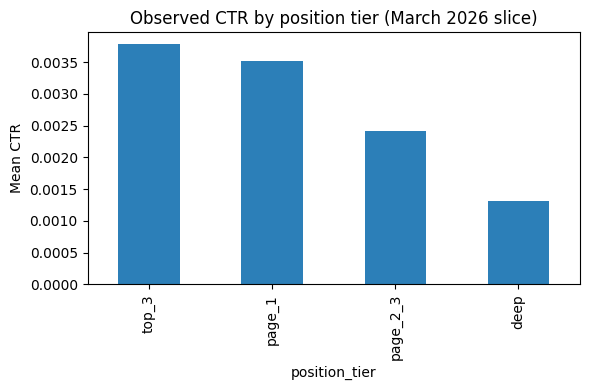

Saved: work/figures/ctr_by_position_tier.png


In [4]:
import matplotlib.pyplot as plt

tier_ctr = agg_filtered.groupby("position_tier", observed=True)["ctr"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 4))
tier_ctr.plot(kind="bar", ax=ax, color="#2c7fb8")
ax.set_ylabel("Mean CTR")
ax.set_title("Observed CTR by position tier (March 2026 slice)")
plt.tight_layout()
plt.savefig("work/figures/ctr_by_position_tier.png", dpi=150)
plt.show()
print("Saved: work/figures/ctr_by_position_tier.png")

## Self-check

- Ranked actions with reason codes explained in plain words. ✅
- Intended use, decision-support framing, and explicit limits stated per the claim ladder. ✅
- Human review steps and a clear no-go list given. ✅
- Monitoring/retrain triggers named. ✅
- Queue CSV and metrics JSON exported to `work/outputs/`; figure saved to `work/figures/`. ✅
- Runs top to bottom with no errors. ✅ — confirm after running
- No client names, URLs, or private queries anywhere. ✅
- Claims use observed/measured/directional/decision-support language throughout, per
  `writing-honest-claims`. ✅
- Committed to my repo under `work/notebooks/`. ✅